# 다룰 내용

- SVM 알고리즘을 이해합니다.

# 1.환경 준비

In [ ]:
# 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings(action='ignore')
%config InlineBackend.figure_format='retina'

* SVM 분류 모델을 시각화 하는 함수를 만든다.

In [2]:
# 시각화 함수 만들기
def svc_visualize(x, y, model, title=''):
    xx, yy = np.meshgrid(np.linspace(x[:, 0].min(), x[:, 0].max(), 50),
                         np.linspace(x[:, 1].min(), x[:, 1].max(), 50))
    Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(5, 5))
    sns.scatterplot(x=x[:, 0], y=x[:, 1], hue=y)
    plt.contour(xx, yy, Z, levels=[-1, 0, 1],
                colors=['gray', 'red', 'gray'],
                linestyles=['--', '-', '--'])
    plt.title(title)
    plt.axis('tight')
    plt.show()

# 2.SVM 기본 개념

- SVM 모델의 기본 개념을 이해한다.

**1) 데이터 만들고 시각화**

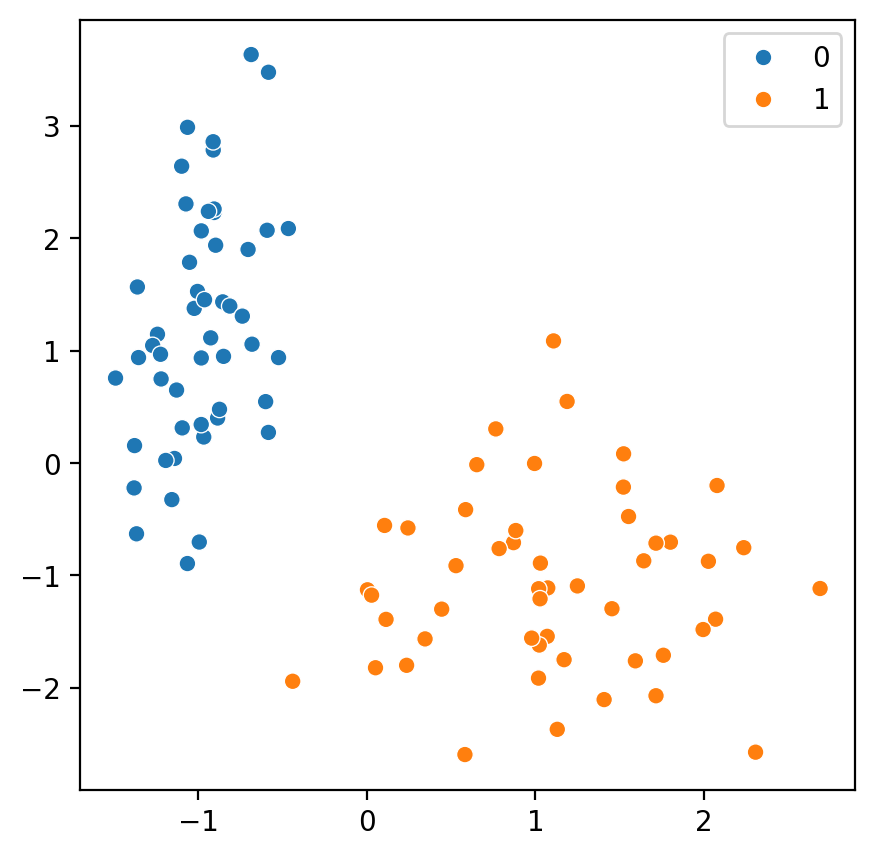

In [3]:
# 데이터 만들기
from sklearn.datasets import make_moons, make_classification

seed = 903
x, y = make_classification(n_samples=100,
                           n_features=2,
                           n_redundant=0,
                           weights=[0.5, 0.5],
                           n_clusters_per_class=1,
                           random_state=seed)

# 시각화
plt.figure(figsize=(5, 5))
sns.scatterplot(x=x[:, 0], y=x[:, 1], hue=y)
plt.show()

**2) 모델링 후 시각화**

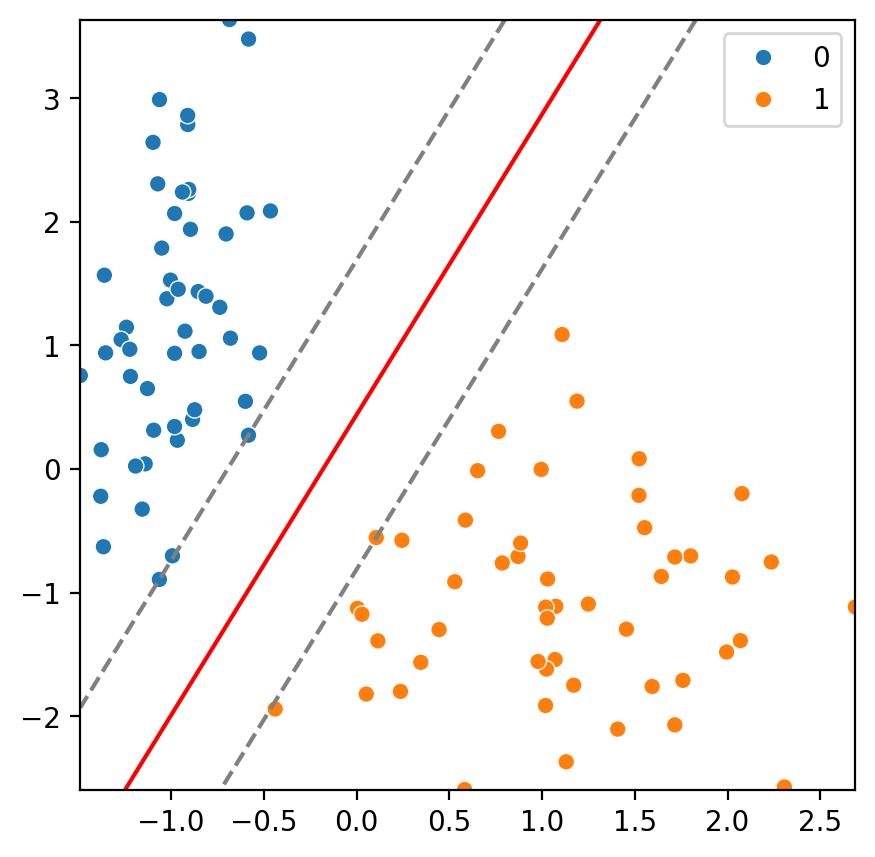

In [4]:
# 불러오기
from sklearn.svm import SVC

# 모델링
# SVM 모델을 생성, 데이터를 직선으로 분류
model = SVC(kernel='linear',        # 선형 커널 이용 - 직선으로 데이터를 분류
            C=10                    # cost
            )
model.fit(x, y)

# 시각화
svc_visualize(x, y, model)

# 3.결정 경계와 마진 이해

**1) 데이터 만들고 시각화**

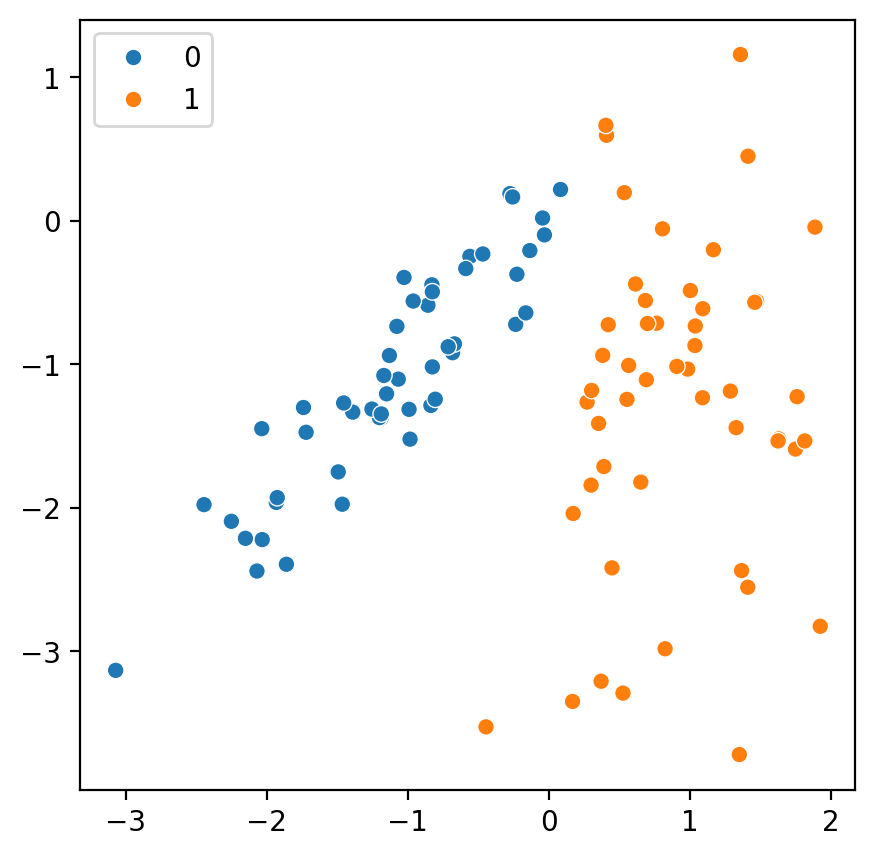

In [5]:
# 데이터 만들기
seed = 874
x, y = make_classification(n_features=2,
                           n_redundant=0,
                           weights=[0.5, 0.5],
                           n_clusters_per_class=1,
                           random_state=seed)

# 시각화
plt.figure(figsize=(5, 5))
sns.scatterplot(x=x[:, 0], y=x[:, 1], hue=y)
plt.show()

**2) cost 값 변경**

* cost 값을 0.1 ~ 40 사이의 숫자로 변경하면서 cost에 따른 모델을 살펴봅시다.

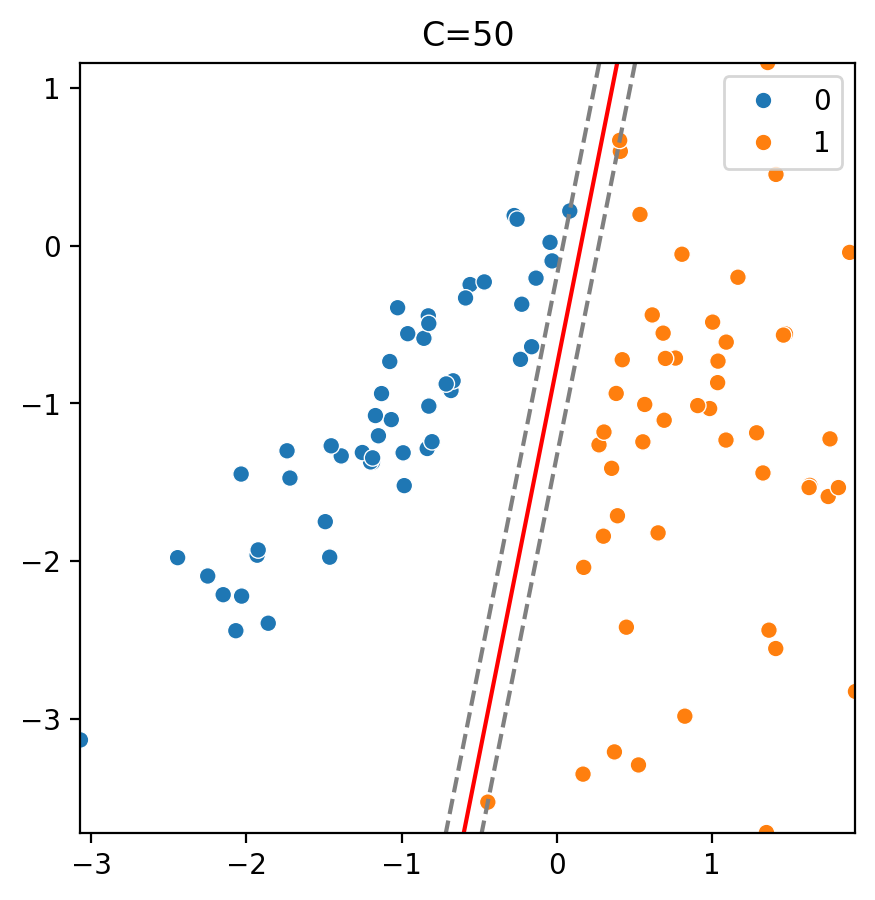

In [6]:
# cost 값
cost = 50

# 모델링
model = SVC(kernel='linear',    # 선형 커널 이용
            C=cost)             # cost
model.fit(x, y)

# 시각화
svc_visualize(x, y, model, f'C={cost}')

In [7]:
# SVM은 기본적으로 두 가지 목표
# 1. 마진 넓게 만드는 것
# 2. 오분류를 줄이는 것

# 4.선형경계로 분류할 수 없는 경우

**1) 데이터 만들고 시각화**

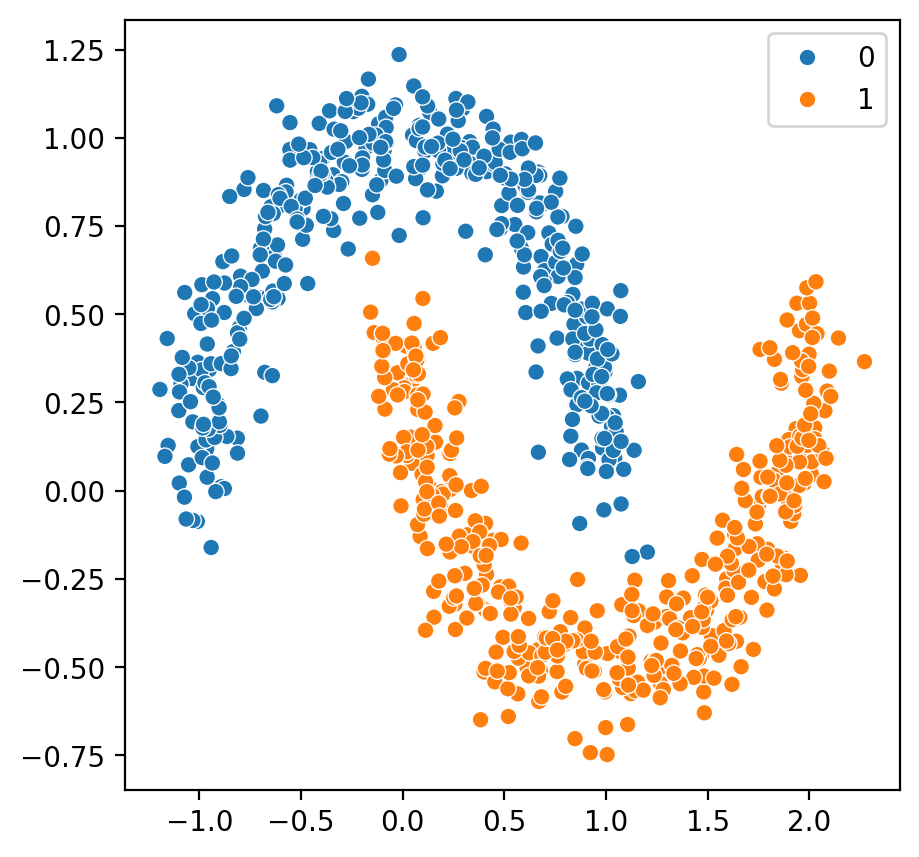

In [8]:
# 데이터 만들기
x, y = make_moons(n_samples=800, noise=.1, random_state=10)

# 시각화
plt.figure(figsize=(5, 5))
sns.scatterplot(x=x[:, 0], y=x[:, 1], hue=y)
plt.show()

**2) 선형경계로 분류**

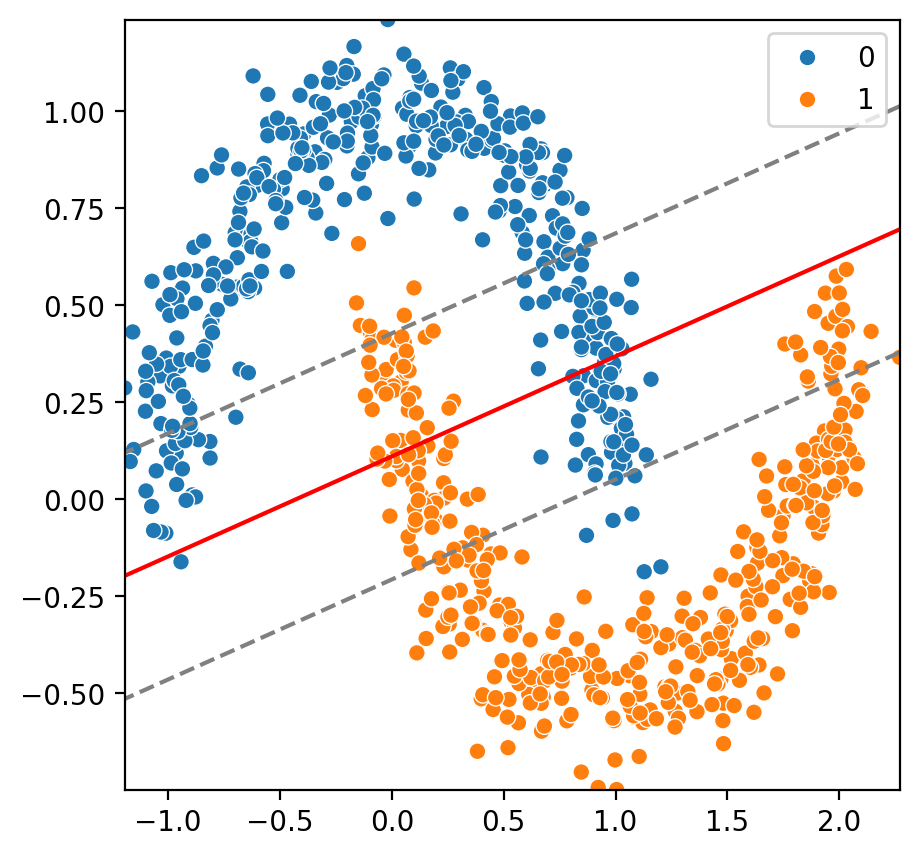

In [9]:
# 모델링
model = SVC(kernel='linear')
model.fit(x, y)

# 시각화
svc_visualize(x, y, model)


**3) 커널 트릭 사용: poly**
- Polynomial
- 모델 선언 시 커널 종류를 지정함

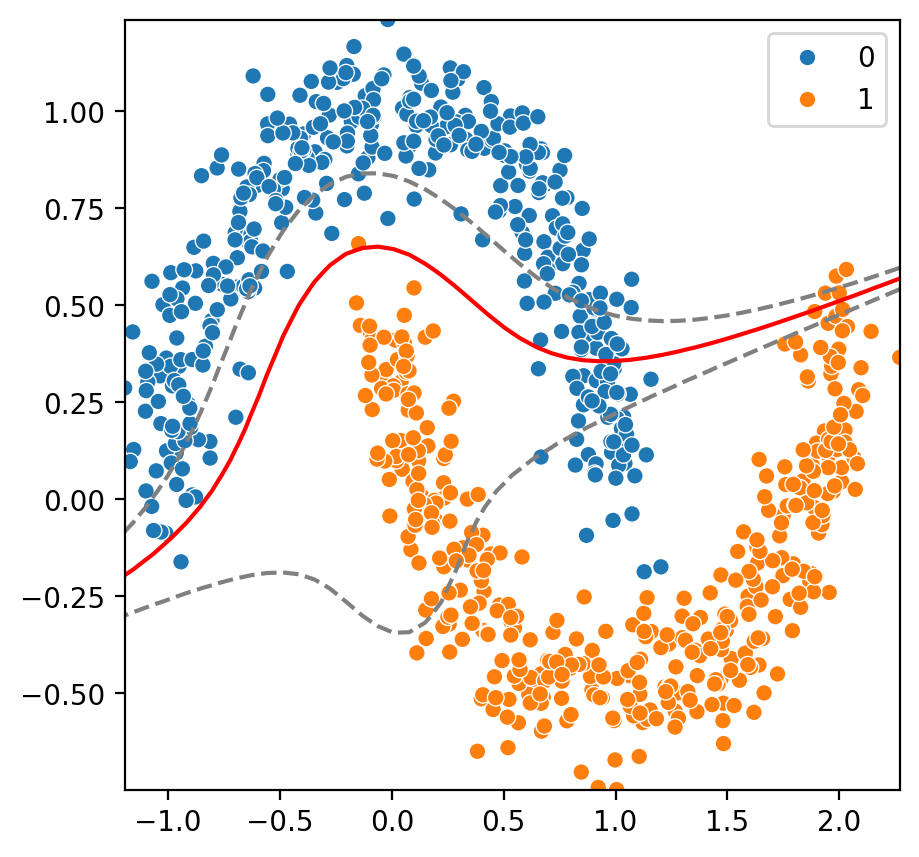

In [10]:
# 모델링
# 곡선형 결정 경계 생성
model = SVC(kernel='poly', C=1)
model.fit(x, y)

# 시각화
svc_visualize(x, y, model)

**4) 커널 트릭 사용 : rbf**
- Radial Basis Function
- 가장 널리 쓰이는 커널(기본값)

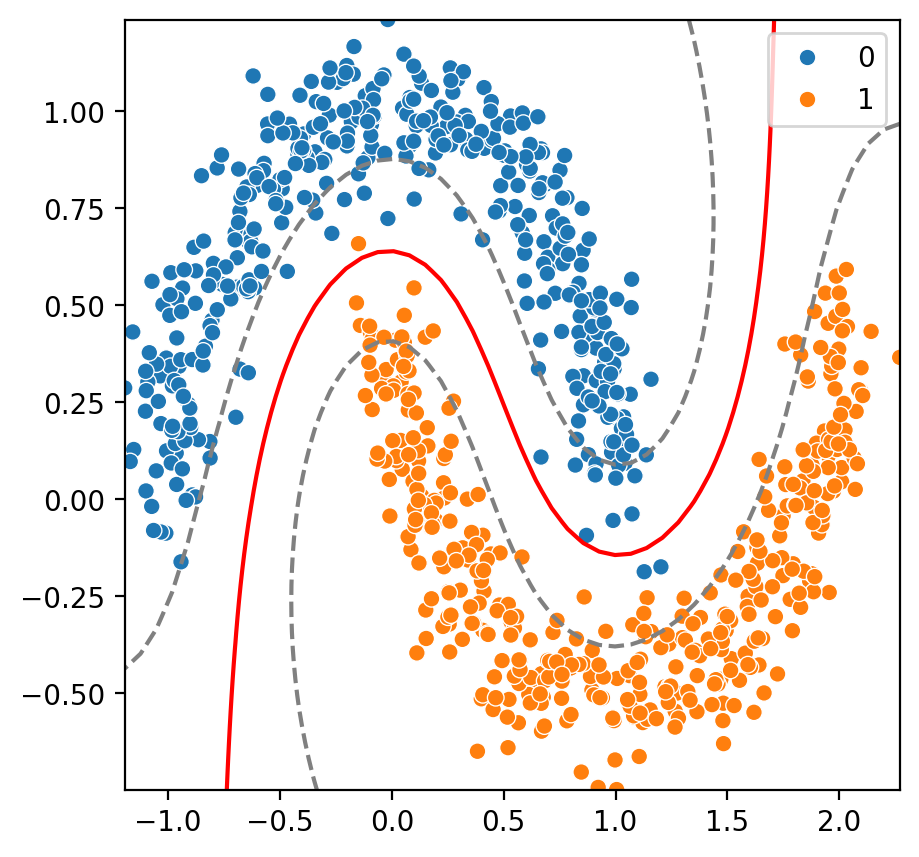

In [11]:
# 모델링
# 가장 인기 있는 커널
# 무한 차원 데이터 변환
model = SVC(kernel='rbf', C=1)
model.fit(x, y)

# 시각화
svc_visualize(x, y, model)

# 5. 하이퍼파라미터

- cost
    - 오류를 허용하지 않으려는 비용(노력!)이다.
    - cost가 증가할 수록
        - 마진의 폭이 줄어들고, 오차를 줄이기 위한 모델이 생성
        - 마진 폭이 줄어들수록 모델이 복잡해짐
- gamma
    - 모델이 생성하는 경계가 복잡해지는 정도(결정 경계의 곡률)
    - 값이 클 수록 작은 표준편자를 가져, 데이터 포인트가 행사하는 영향력이 줄어듦
    - 값이 낮을 수록 데이터 포인터가 영향력을 행사하는 거리가 길어져 경계가 단순해짐
    - C 처럼 너무 낮으면 과소적합(Underfitting), 너무 높으면 과대적합(Overfitting) 위험

**1) cost에 따른 결정 경계**

- cost에 따라 결정 경계가 어떻게 달라지는지 살펴 보자

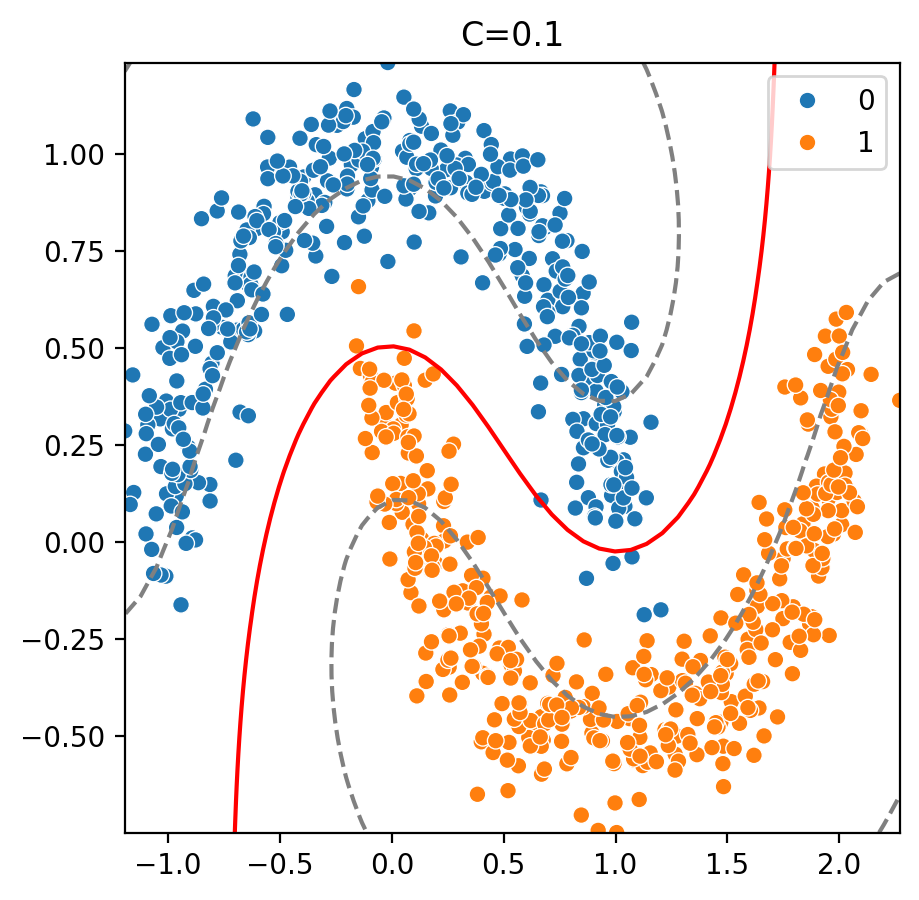

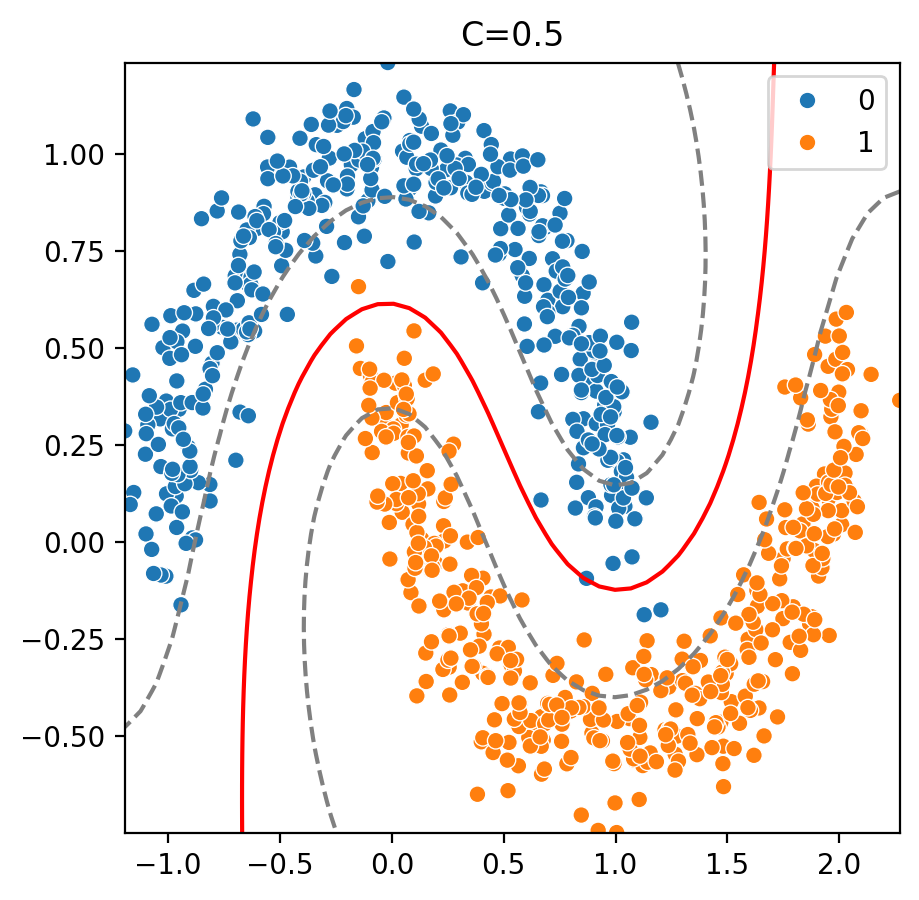

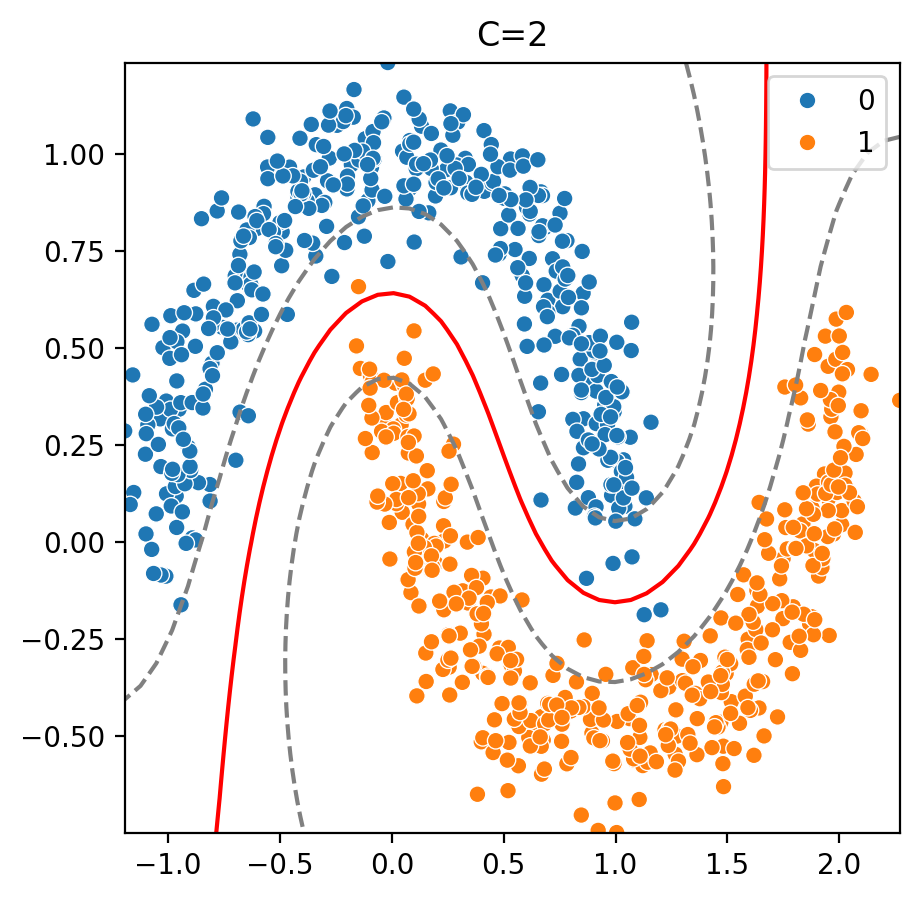

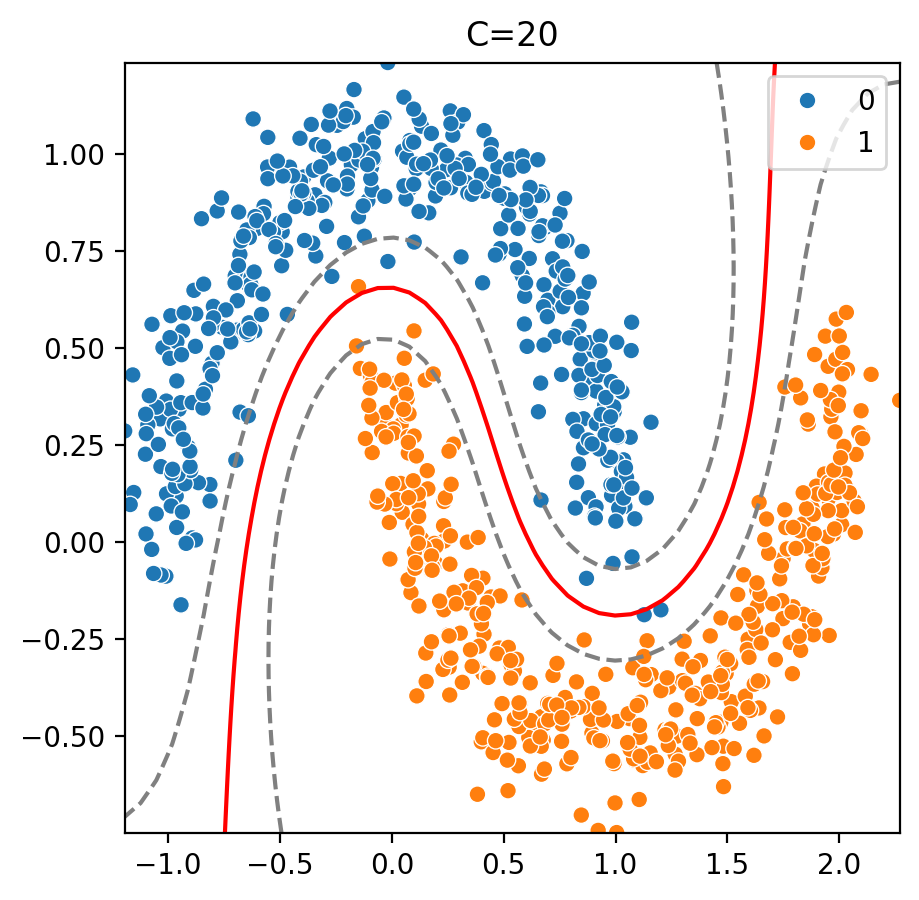

In [12]:
# cost에 따른 결정 경계
cost_list = [0.1, 0.5, 2, 20]

for cost in cost_list:
    model = SVC(kernel='rbf', C=cost)
    model.fit(x, y)
    svc_visualize(x, y, model, f'C={cost}')

**2) gamma에 따른 결정 경계**

- gamma에 따라 결정 경계가 어떻게 달라지는지 살펴 보자

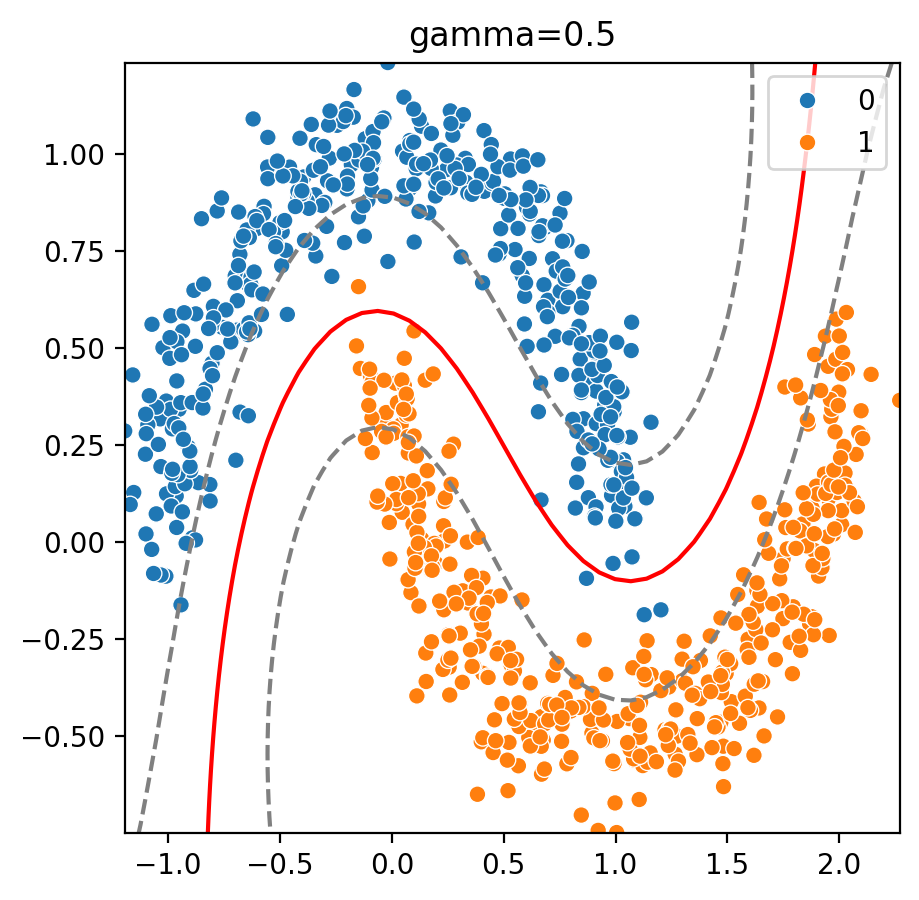

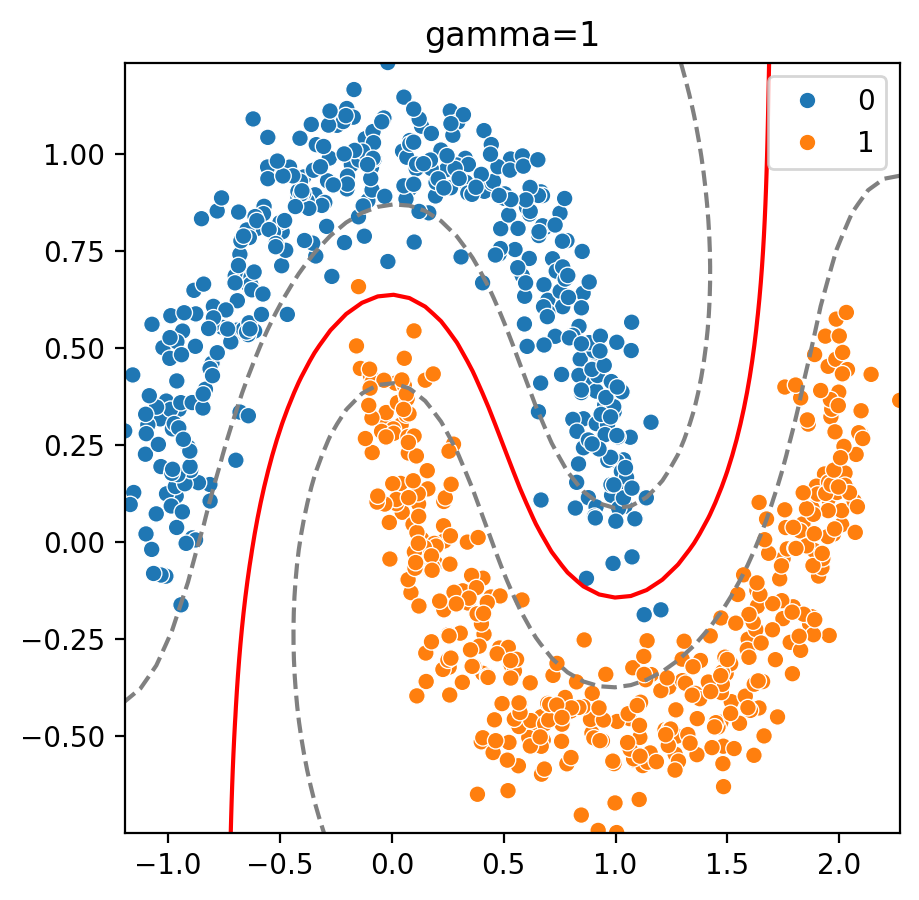

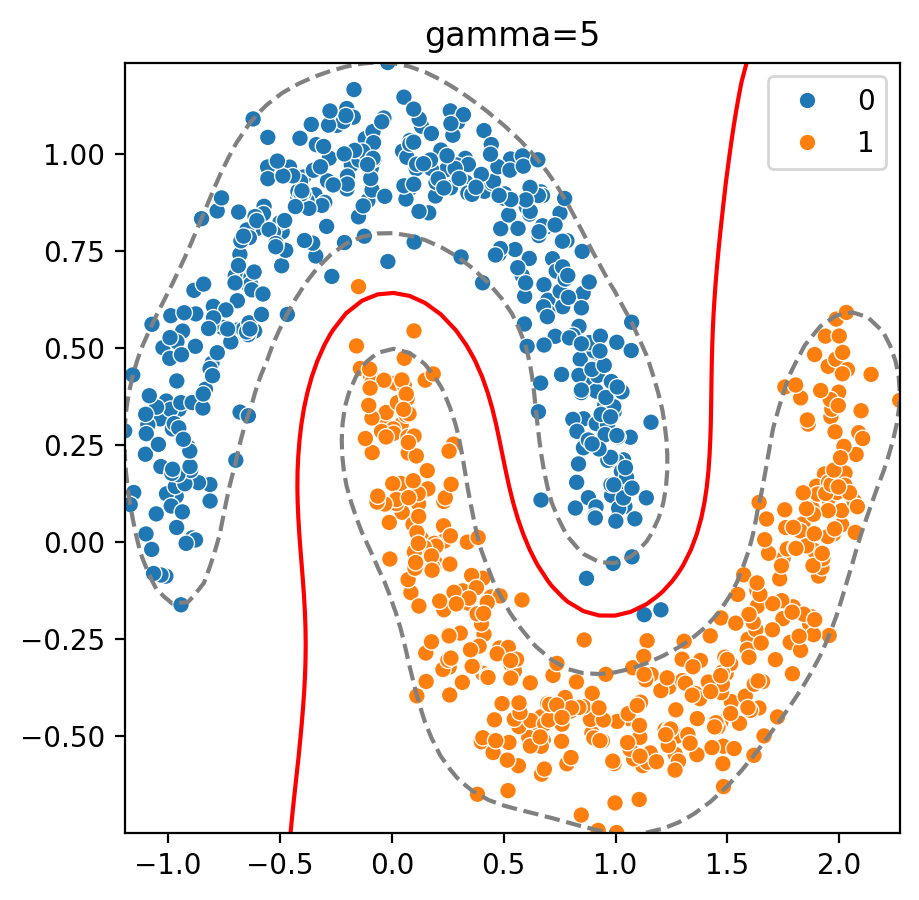

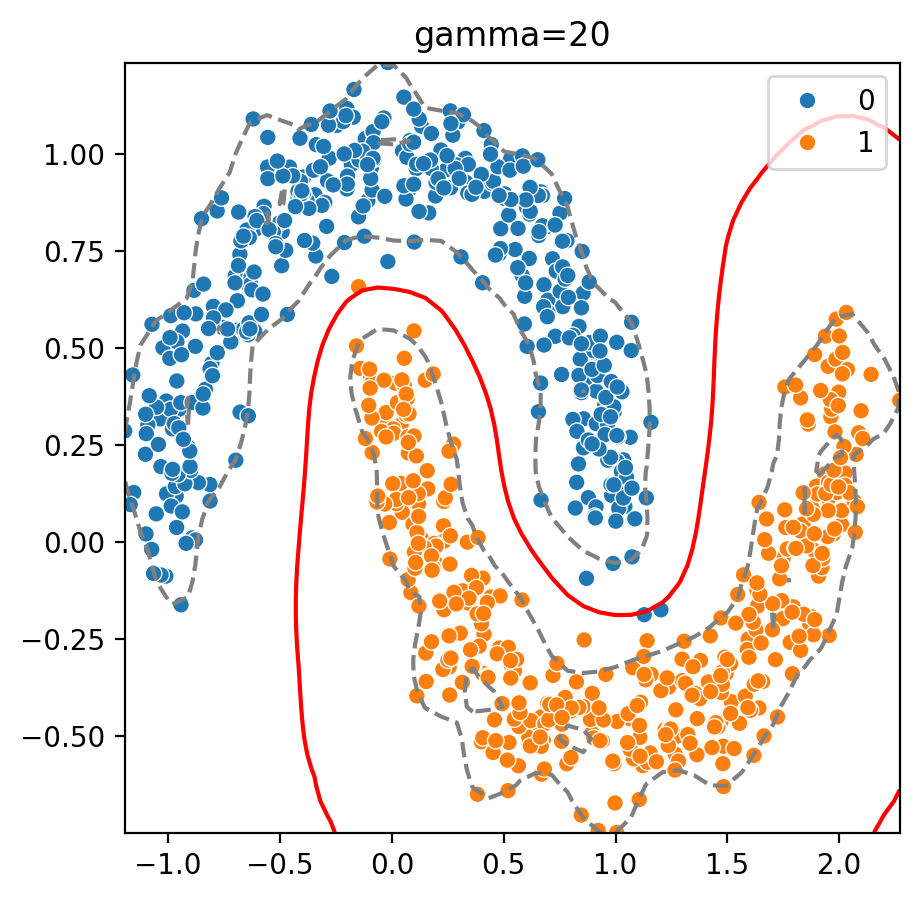

In [13]:
# gamma에 따른 결정 경계
# gamma는 하나의 데이터 포인트가 주변에 얼마나 큰 영향력을 미치는가를 정하는 값
# gamma 작음 = 부드러움 경계
# gamma 큼 = 복잡한 경계
gamma_list = [0.5, 1, 5, 20]
for g in gamma_list:
    model = SVC(kernel='rbf', C=1, gamma=g)
    model.fit(x, y)
    svc_visualize(x, y, model, f'gamma={g}')

# 6. 회귀 모델

- SVM 회귀 모델을 시각화 하는 함수를 만든다.

In [14]:
# 시각화 함수 만들기
def svr_visualize(x, y, model, title=''):
    xx = np.linspace(x.min(), x.max(), 50)
    xx = xx.reshape((len(xx), 1))
    yy = model.predict(xx)

    plt.figure(figsize=(5, 5))
    plt.scatter(x, y, edgecolors='w', linewidths=0.5)
    plt.plot(xx, yy, color = 'r')
    plt.plot(xx, yy + model.epsilon, color = 'gray', linestyle='--')
    plt.plot(xx, yy - model.epsilon, color = 'gray', linestyle='--')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(title)
    plt.axis('tight')
    plt.show()

- Sample 데이터를 만들고 시각화한다.

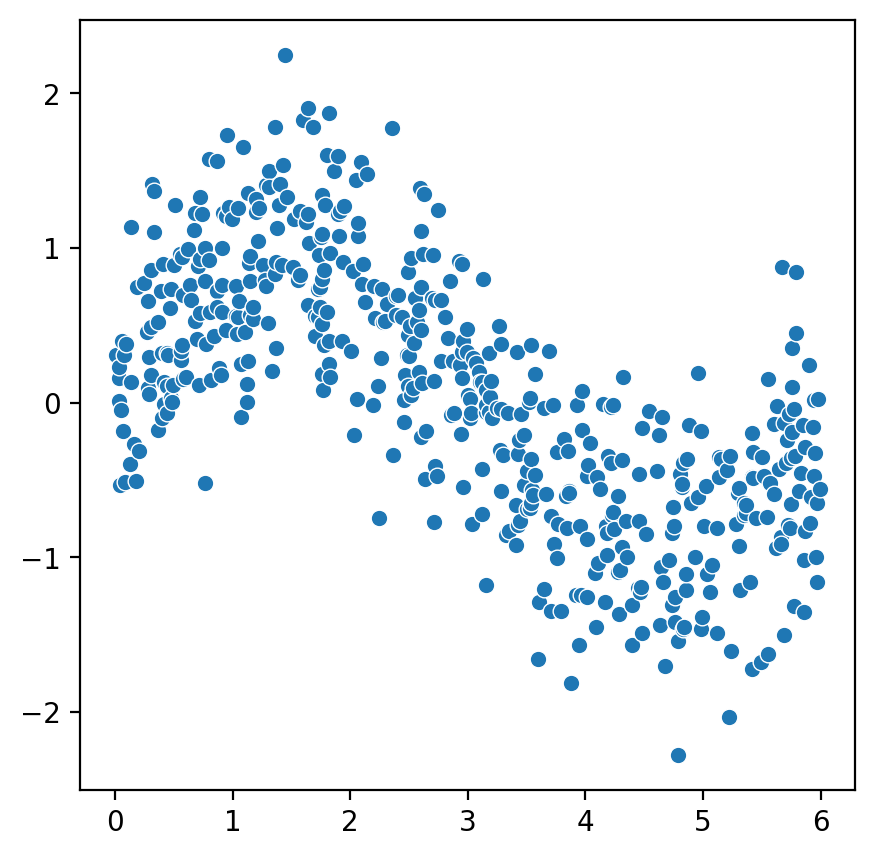

In [15]:
# 데이터 만들기
from sklearn.datasets import make_moons, make_regression

numSamples = 500
x = np.sort(6 * np.random.rand(numSamples, 1), axis=0)
y = np.sin(x).ravel()
y = y + 0.5 * (np.random.randn(numSamples))

# 시각화
plt.figure(figsize=(5, 5))
plt.scatter(x, y, edgecolors='w', linewidths=0.5)
plt.show()

- 모델을 만들고 시각화한다.

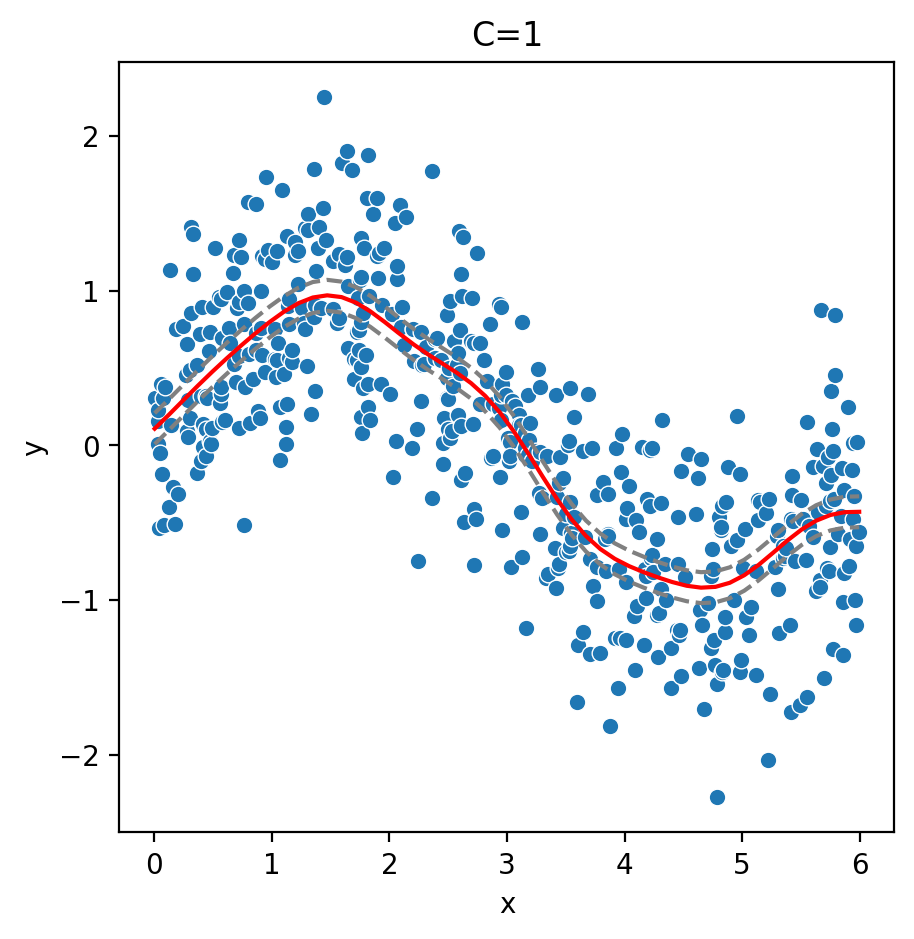

In [16]:
# 불러오기
from sklearn.svm import SVR

# 모델링
cost = 1
model = SVR(kernel='rbf', C=cost, gamma=1)
model.fit(x, y)

# 시각화
svr_visualize(x, y, model, f'C={cost}')

- cost 변화에 따른 곡선의 변화를 확인한다.

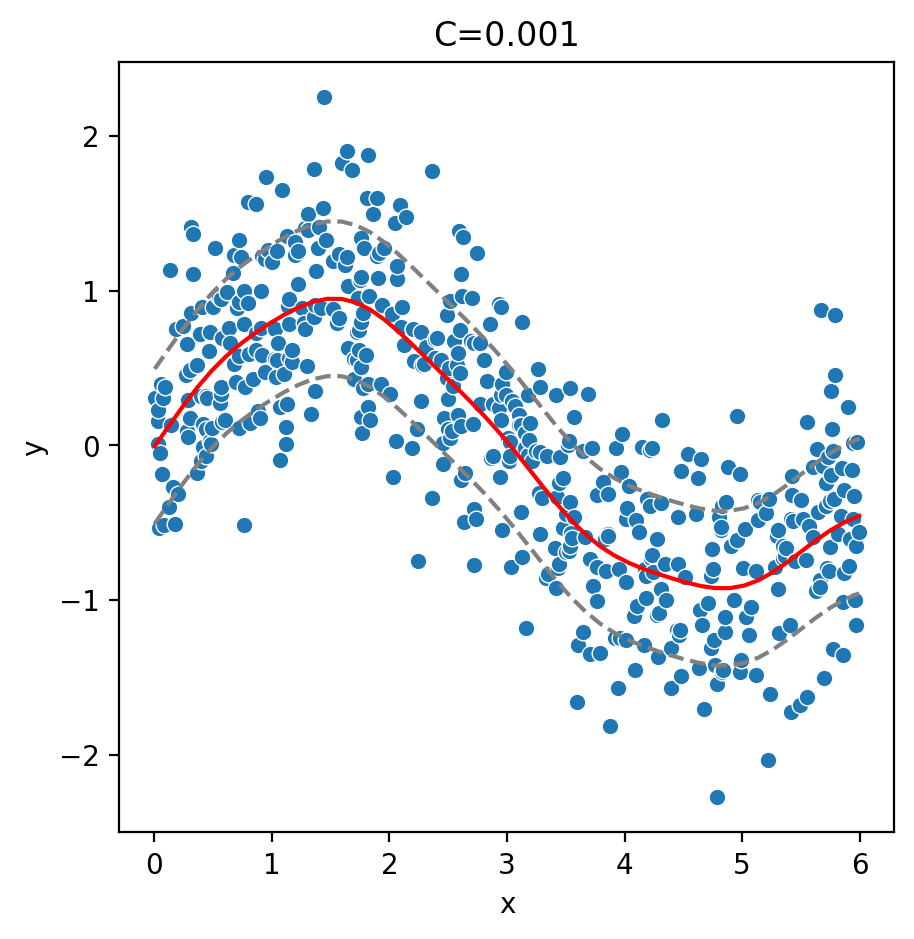

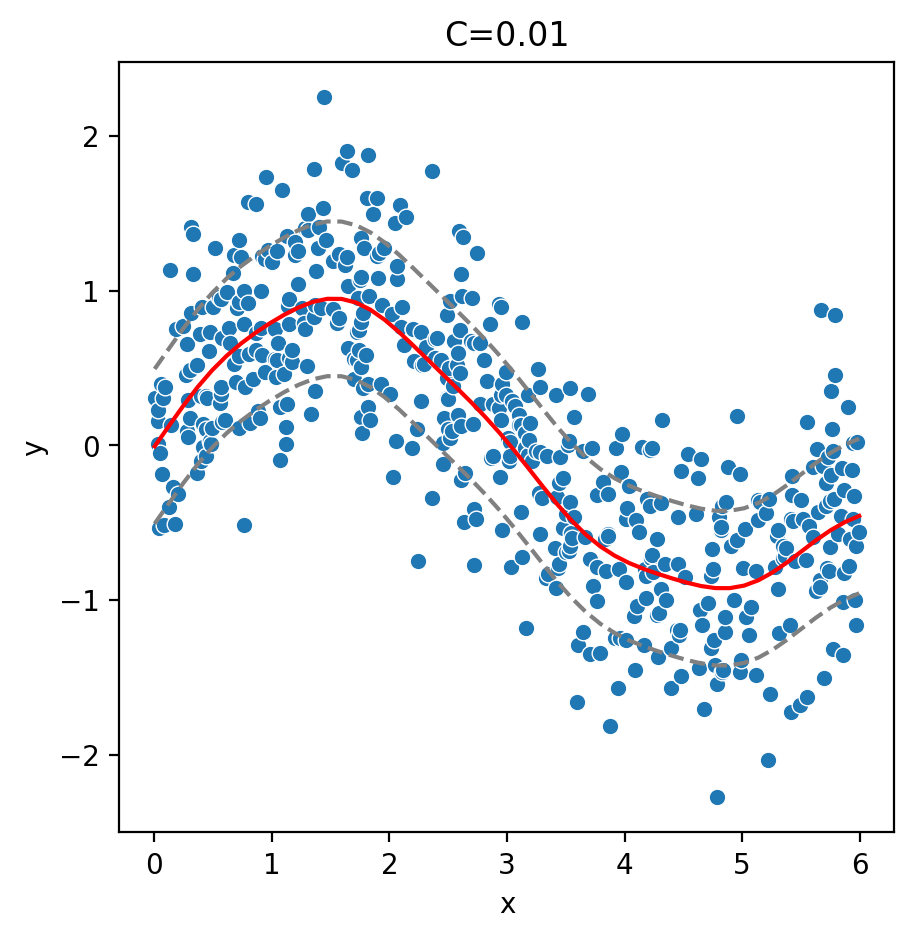

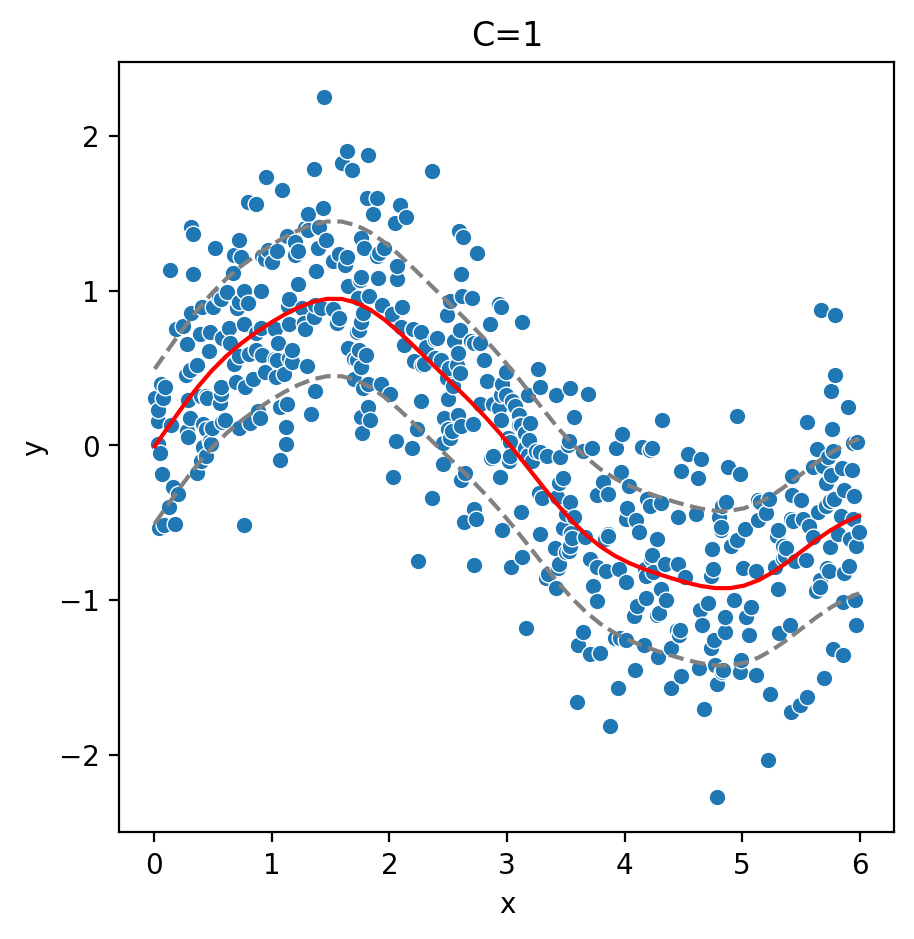

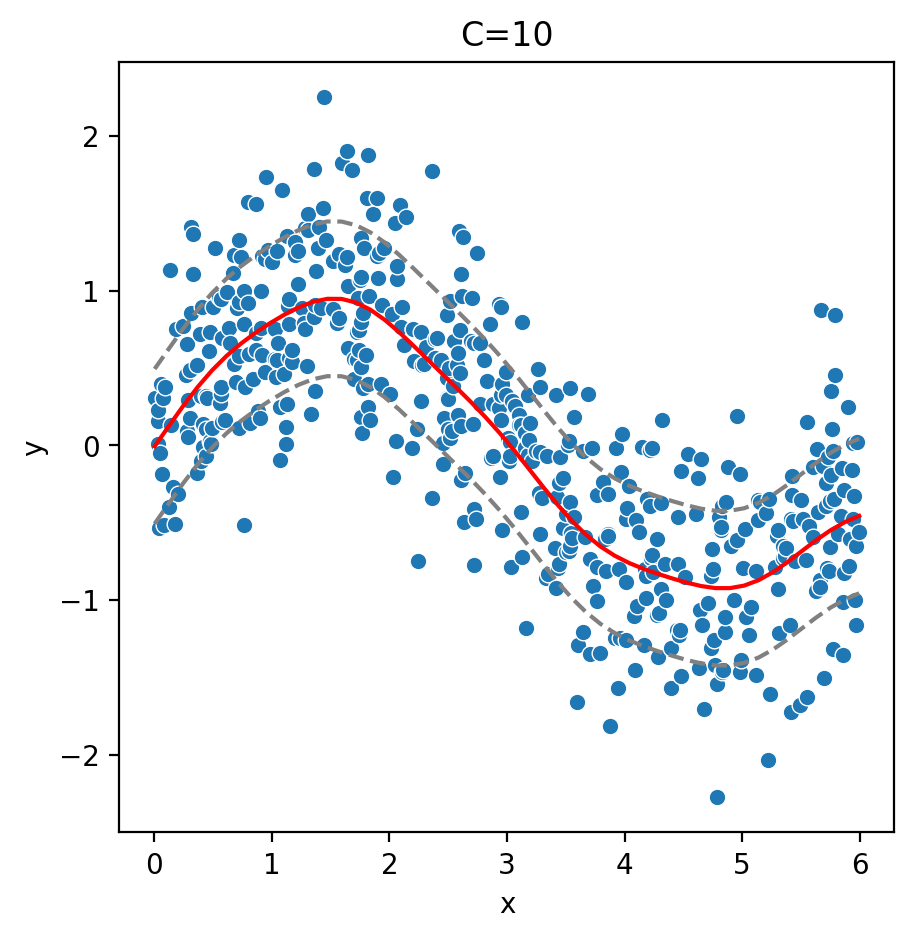

In [17]:
# cost에 따른 결정 경계
cost_list2 = [0.001, 0.01, 1, 10]

for cost in cost_list2:
    model = SVR(kernel='rbf', gamma=1, epsilon=0.5)  
    model.fit(x, y)                                     
    svr_visualize(x, y, model, f'C={cost}')